<a href="https://colab.research.google.com/github/PriyadarshanSingh/Deep-Learning/blob/main/Neukjral__Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is regarding the basics of a deep learning neural network.

In [1]:
import torch
import torch.nn as nn
print(torch.__version__)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.optim as optim
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

2.8.0+cu126


# Load data
1. Convert them inot tensor of right data type(torch.float)
2. Make sure they have right dimension
3. Do statndard scalar process(mean and std variation)


In [2]:
X=torch.arange(0,5,0.02).unsqueeze(dim=1)

y=torch.sin(X)+torch.randn(len(X))*0.9


X_test,X_train,y_test,y_train=train_test_split(X,y,test_size=0.3)

# Constructing a neural network


In [3]:
class Sin(nn.Module):
  def __init__(self):
    super().__init__()
    self.way=nn.Sequential(
          nn.Linear(1, 64),
          nn.ReLU(),
          nn.Linear(64, 64),
         nn.ReLU(),
          nn.Linear(64, 1)
    )

  def forward(self,X):
    return self.way(X)

model=Sin()

# loss function  initialisation
loss_fn=nn.MSELoss()

#optimizer selection
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

# Training  of neural network

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([75, 250])) that is different to the input size (torch.Size([75, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([175, 250])) that is different to the input size (torch.Size([175, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epochs:0|Loss:1.4395220279693604|Test Loss:1.295520305633545
Epochs:250|Loss:0.7581443786621094|Test Loss:0.7576530575752258
Epochs:500|Loss:0.7577384114265442|Test Loss:0.7572987675666809
Epochs:750|Loss:0.7574645280838013|Test Loss:0.7570978403091431
Epochs:1000|Loss:0.7572619318962097|Test Loss:0.7569592595100403
Epochs:1250|Loss:0.7570913434028625|Test Loss:0.7568256258964539
Epochs:1500|Loss:0.7570119500160217|Test Loss:0.7567510604858398
Epochs:1750|Loss:0.7569467425346375|Test Loss:0.7567020654678345
Epochs:2000|Loss:0.7568870186805725|Test Loss:0.756668746471405
Epochs:2250|Loss:0.7568283081054688|Test Loss:0.7566397190093994
Epochs:2500|Loss:0.75677090883255|Test Loss:0.7566192150115967
Epochs:2750|Loss:0.7567110657691956|Test Loss:0.7565975785255432
Epochs:3000|Loss:0.7566596865653992|Test Loss:0.7565833926200867
Epochs:3250|Loss:0.7566210627555847|Test Loss:0.7565777897834778
Epochs:3500|Loss:0.7565948963165283|Test Loss:0.7565696239471436
Epochs:3750|Loss:0.7566072940826416

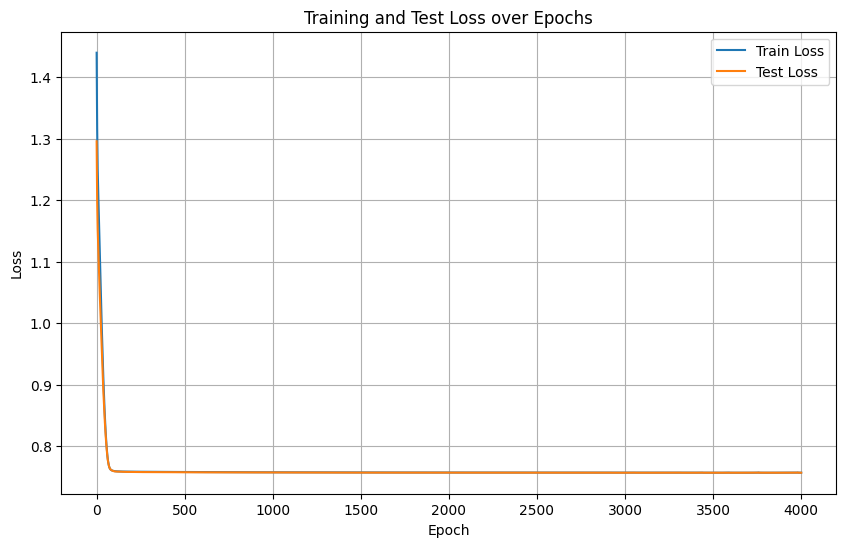

In [4]:

epochs=4001
epoch_count=[]
loss_values=[]
test_loss_values=[]

for epoch in range(epochs):
  model.train()

  y_preds=model(X_train)

  loss=loss_fn(y_preds,y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()
  # Testing
  model.eval()
  with torch.inference_mode():
    test_pred=model(X_test)

    test_loss=loss_fn(test_pred,y_test)
      # Store epoch and losses
    epoch_count.append(epoch)
    loss_values.append(loss.item())
    test_loss_values.append(test_loss.item())
  if epoch%250==0:
    print(f"Epochs:{epoch}|Loss:{loss}|Test Loss:{test_loss}")

plt.figure(figsize=(10,6))
plt.plot(epoch_count, loss_values, label='Train Loss')
plt.plot(epoch_count, test_loss_values, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()
